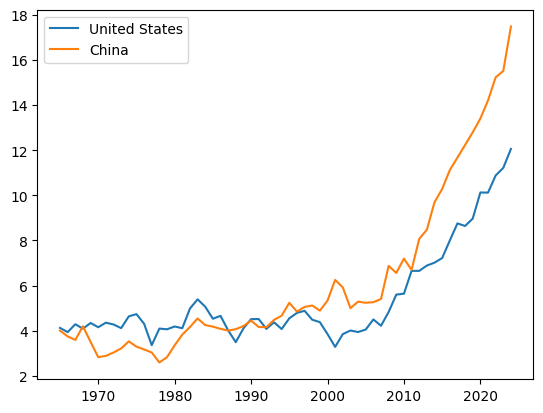

1965


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from prophet import Prophet
#'pd' for example is a library naming convention

df = pd.read_csv("owid-energy-data.csv")
#pd.read_csv ALWAYS returns a dataframe
#if you want to check type: print(type(df))
#pd.read_csv tells pandas to open and read the file 
#it's a method/function that is within pandas
#object.method(inputs)


#print(df.head())
#dataframe itself is an object with builtin functions
#df.head() are the first 5 ROWS of dataframe
#the header row is not included in the 5

#arrow -> means the TYPE the fn returns
#default for df.head is 5 rows

#STEP 2: filter the data
countries = ["United States", "China"]

#dataframe is indexable by row position AND column string
#first: index by column name
countries_column = df["country"] #TYPE: SERIES
boolean_series = countries_column.isin(countries) #TYPE: SERIES 
#isin method loops over every entry in the column and checks against countries list

#print(type(countries_column))
#print(type(row_indices))

#second: index by rows
filtered_df = df[boolean_series]
#filtered dataframe includes all the rows whose country column is US or China
#all columns are kept, only rows are filtered

#SUMMARY: 
    #filtering rows: index df using a boolean series df[df["column"].isin(columnlist)]
    #filtering columns: pass in list of column names df[['x', 'y']]
    
#print(filtered_df)

#make plot of total energy usage over time
#make plot of energy share over time

#make plot of renewable share energy over time:
#further filtering columns to include only share of energy over time for diff. sources
#how can we ensure there is no overlap?
renewables_share = filtered_df[["country", "year","renewables_share_energy"]]
#important: columns excluded because they are sumer: 
#  fossil(coal,oil,gas),renewable(solar,wind,hydro,other),low carbon(renew,nuclear)


#filter by rows
us_bool = renewables_share["country"].isin(["United States"])
us_df = renewables_share[us_bool]

china_bool = renewables_share["country"].isin(["China"])
china_df = renewables_share[china_bool]

plt.plot(us_df["year"], 
us_df["renewables_share_energy"], 
label="United States")  
    
plt.plot(china_df["year"], 
china_df["renewables_share_energy"],
label="China")
#what does the plot method do if there are NA y-values
#the data values are skipped

plt.legend()
plt.savefig("renewables_share_energy.png")
plt.show() #both datasets on one graph
#did not filter the dataframe to remove NA values, but no gaps appear in the graph 
#no gaps appear because all missing data is before 1965, so the graph starts then
#next time, it is good practice to filter beforehand
#if missing data is left: matplotlib leaves gaps
#if missing data is removed: smooth line drawn

#print(us_df[us_df["renewables_share_energy"].notna()]["year"].min())
#filters dataframe rows and then only takes the years

#to embed image: ![title](file_name)
#IMPORTANT: must save fig before showing
#showing visualizes and then clears


**Initial Observations of renewables share of total energy consumption over time**
- renewables energy share for both countries grew from about 4% to about 12% for the US and 18% for China
- China's renewables share started as (on average) less than that of the United States' share until around 1990 when China's share began to grow while the United States' remained stagnant
- The United states' share started to grow in 2005 - 15 years after China's
- the rate of growth seems to be greater for China

NOTE: renewables include solar, wind, hydro, nuclear, and other sources

**Historical Context**

**<u>Next Step: Decomposition</u>** (Trend, Seasonality, Residual)

60
126


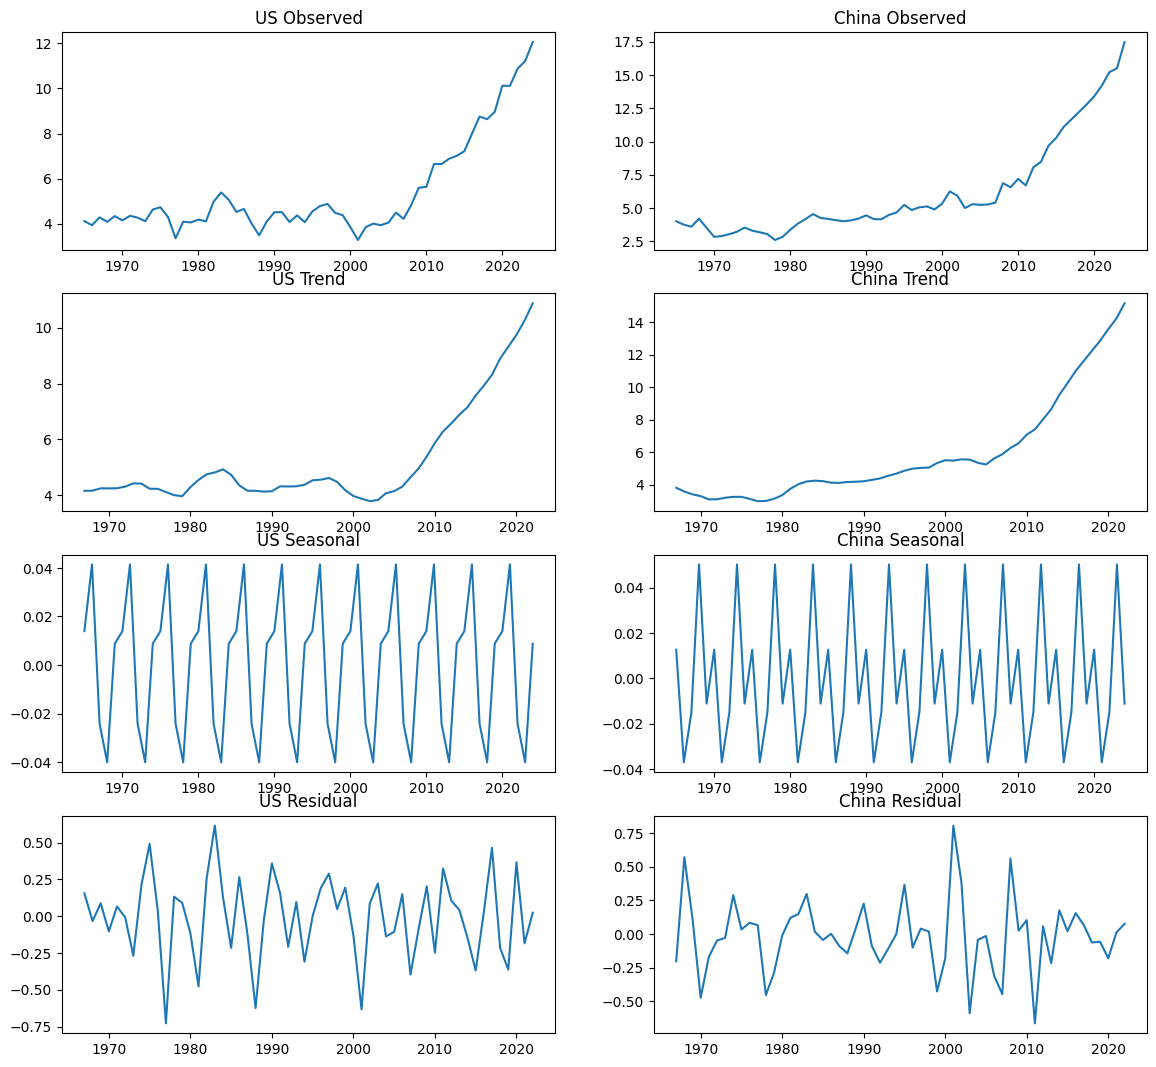

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

us_df_renewables = us_df.set_index("year")["renewables_share_energy"]
#only include entries with values
us_df_renewables = us_df_renewables.dropna()

us_decomp = seasonal_decompose(us_df_renewables, model= "additive",period =5)

china_df_renewables = china_df.set_index("year")["renewables_share_energy"]
china_df_renewables = china_df_renewables.dropna()

china_decomp = seasonal_decompose(china_df_renewables, model="additive",period=5)

fig, axes = plt.subplots(4, 2, figsize=(14,13))

print (len(us_df_renewables))#60
print (len(us_df))#126

#there was a mismatch in number of x-axis years and y-axis shares
# this is because shares were filtered to remove NA values
# repeat the same to filter years: 
us_df_clean = us_df.dropna(subset=["renewables_share_energy"])
#removes all NA entries in the specifies columns
china_df_clean = china_df.dropna(subset=["renewables_share_energy"])
#axes[row, col]
#plotting decomposed renewables share values vs time
#the us_decomp is a DecomposeResult type that took in the y values only
#.values method removes the indexes from dataframes preventing misalignment

axes[0,0].plot(us_df_clean["year"].values, us_decomp.observed)
axes[0,0].set_title("US Observed")
axes[1,0].plot(us_df_clean["year"].values, us_decomp.trend)
axes[1,0].set_title("US Trend")
axes[2,0].plot(us_df_clean["year"].values,us_decomp.seasonal)
axes[2,0].set_title("US Seasonal")
axes[3,0].plot(us_df_clean["year"].values, us_decomp.resid)
axes[3,0].set_title("US Residual")

axes[0,1].plot(china_df_clean["year"].values, china_decomp.observed)
axes[0,1].set_title("China Observed")
axes[1,1].plot(china_df_clean["year"].values, china_decomp.trend)
axes[1,1].set_title("China Trend")
axes[2,1].plot(china_df_clean["year"].values,china_decomp.seasonal)
axes[2,1].set_title("China Seasonal")
axes[3,1].plot(china_df_clean["year"].values, china_decomp.resid)
axes[3,1].set_title("China Residual")

plt.savefig("decomposition.png")
plt.show()



**Interpretation of Decomposition Results**

Trend - the observed data versus time, with noise removed
- renewables share starts at about 4% for both countries
- upward trend for both countries; rate of growth seems similar with US growth starting in 2000 and China growth starting in 1990 and accelerating in 2005

Seasonal - reflects patterns every 5 periods
- seasonality is not meaningful because the data is annual meaning there is only one data point per year. There is no socioeconomic cycle repeating across years meaning season analysis outputs cannot be interpreted.

Residual - variation in data from the trend
- US: upward variation in 1975, 1985, 2017, 2020; downward variation in 1977, 1988, 2001
- China: upward variation in 1965, 2000, 2008; downward variation in 1970, 1978, 2003, 2011

It is important to note that upward and downward variation is not an indication that renewable energy output itself increased/decreased, but that its percentage makeup of total energy output did. Renewables energy share can increase or decrease if the amount of non-renewable energy consumed increases or decreases.

**Also, when are residual values considered to reflect significant variation?**
A general rule of thumb is 1.5 standard deviations from the zero residual value.





In [31]:
#residuals >1.5 SD from mean
us_std = us_decomp.resid.std()
us_mean = us_decomp.resid.mean()
us_sig_var = us_decomp.resid[abs(us_decomp.resid - us_mean) > 1.5*us_std]

for year, value in us_sig_var.items():
    direction = "upward" if value > 0 else "downward"
    print(f"US: {year}, {direction} ({value: 0.2f})")

china_std = china_decomp.resid.std()
china_mean = china_decomp.resid.mean()
china_sig_var = china_decomp.resid[abs(china_decomp.resid - china_mean) > 1.5*china_std]

for year, value in china_sig_var.items():
    direction = "upward" if value > 0 else "downward"
    print(f"China: {year}, {direction} ({value: 0.2f})")

US: 1975, upward ( 0.49)
US: 1977, downward (-0.73)
US: 1981, downward (-0.48)
US: 1983, upward ( 0.62)
US: 1988, downward (-0.62)
US: 2001, downward (-0.63)
US: 2017, upward ( 0.46)
China: 1968, upward ( 0.57)
China: 1970, downward (-0.47)
China: 1978, downward (-0.45)
China: 1999, downward (-0.43)
China: 2001, upward ( 0.81)
China: 2003, downward (-0.59)
China: 2007, downward (-0.45)
China: 2008, upward ( 0.56)
China: 2011, downward (-0.66)


**Historical Events Compared to Data**

compare historical events such as policy/financial market/climate/etc. and what they would predict about changes in renewable energy share and compare to results

**Forecasting**

00:44:08 - cmdstanpy - INFO - Chain [1] start processing
00:44:09 - cmdstanpy - INFO - Chain [1] done processing


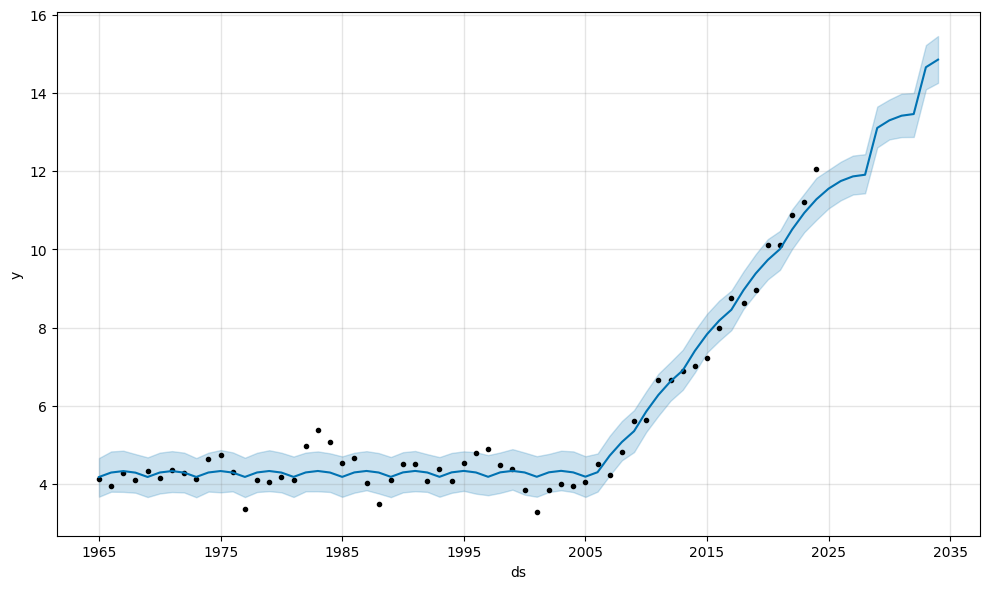

<Figure size 640x480 with 0 Axes>

In [ ]:
#use Prophet for forecasting
#need to make dataframe with col "ds" = datestamp and "y" values for forecasting

us_prophet = us_df[["year", "renewables_share_energy"]].dropna()
us_prophet = us_prophet.rename(columns = {"year":"ds", "renewables_share_energy":"y"})

#this line converts year to datetime ex. year-month-day
us_prophet["ds"] = pd.to_datetime(us_prophet["ds"], format="%Y")

us_model = Prophet() #play on words?
us_model.fit(us_prophet)
us_future = us_model.make_future_dataframe(periods=10,freq="YE")
us_forecast = us_model.predict(us_future)

us_model.plot(us_forecast)
plt.show()
plt.savefig("us_forecasting_png")